In [ ]:
import torch
import numpy as np
import torch.optim as optim
import torch.nn as nn
import math

In [ ]:
batch_size = 32
sequence_length = 100
vocab_size = 5000
embedding_dim = 128

In [ ]:
input = torch.ones(batch_size,sequence_length,dtype=torch.long)
input

tensor([[1, 1, 1,  ..., 1, 1, 1],
        [1, 1, 1,  ..., 1, 1, 1],
        [1, 1, 1,  ..., 1, 1, 1],
        ...,
        [1, 1, 1,  ..., 1, 1, 1],
        [1, 1, 1,  ..., 1, 1, 1],
        [1, 1, 1,  ..., 1, 1, 1]])

In [ ]:
input.shape

torch.Size([32, 100])

In [ ]:
class InputEmbedding(nn.Module):
  def __init__(self,vocab_size,embedding_dim):
    super().__init__()
    self.embedding = nn.Embedding(vocab_size,embedding_dim)
  def forward(self,X):
    return self.embedding(X)

In [ ]:
input_model = InputEmbedding(vocab_size,embedding_dim)

In [ ]:
input_model

InputEmbedding(
  (embedding): Embedding(5000, 128)
)

In [ ]:
input_ = input_model(input)

In [ ]:
input_

tensor([[[ 0.5952, -0.5881,  0.2145,  ...,  0.4709,  1.0550, -0.0783],
         [ 0.5952, -0.5881,  0.2145,  ...,  0.4709,  1.0550, -0.0783],
         [ 0.5952, -0.5881,  0.2145,  ...,  0.4709,  1.0550, -0.0783],
         ...,
         [ 0.5952, -0.5881,  0.2145,  ...,  0.4709,  1.0550, -0.0783],
         [ 0.5952, -0.5881,  0.2145,  ...,  0.4709,  1.0550, -0.0783],
         [ 0.5952, -0.5881,  0.2145,  ...,  0.4709,  1.0550, -0.0783]],

        [[ 0.5952, -0.5881,  0.2145,  ...,  0.4709,  1.0550, -0.0783],
         [ 0.5952, -0.5881,  0.2145,  ...,  0.4709,  1.0550, -0.0783],
         [ 0.5952, -0.5881,  0.2145,  ...,  0.4709,  1.0550, -0.0783],
         ...,
         [ 0.5952, -0.5881,  0.2145,  ...,  0.4709,  1.0550, -0.0783],
         [ 0.5952, -0.5881,  0.2145,  ...,  0.4709,  1.0550, -0.0783],
         [ 0.5952, -0.5881,  0.2145,  ...,  0.4709,  1.0550, -0.0783]],

        [[ 0.5952, -0.5881,  0.2145,  ...,  0.4709,  1.0550, -0.0783],
         [ 0.5952, -0.5881,  0.2145,  ...,  0

In [ ]:
input_.shape ## each word is now converted in 128 dim vector

torch.Size([32, 100, 128])

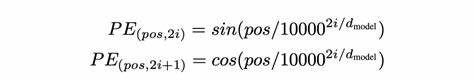

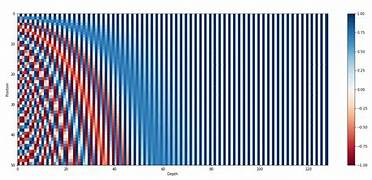

In [ ]:
class PositionalEncoding(nn.Module):
  def __init__(self,vocab_size,embedding_dim,seq_len):
    super().__init__()
    self.seq_len = seq_len
    self.d_k = embedding_dim
    pe = torch.zeros(seq_len,embedding_dim)
    print(pe.shape)
    div = torch.exp(torch.arange(0,self.d_k,2).float() * (-math.log(1000.0)/self.d_k))
    position = torch.arange(0,seq_len,dtype=torch.float).unsqueeze(1)
    pe[:,0::2] = torch.sin(position*div)
    pe[:,1::2] =  torch.cos(position*div)
    print(pe.shape)
    pe = pe.unsqueeze(0) # to convert to batch
    self.register_buffer("pe",pe)
    print(pe.shape)

  def forward(self,X):
    return X + (self.pe[:,:self.seq_len,:]).requires_grad_(False)

In [ ]:
# input_embedding = [batch_size,seq_len,embedding]
# positional encoding = [batch_size,seq_len,embedding]
## ---- adding

# positional batch_size = unseqeeze(0)
# pe = [seq_len,embedding_dim] = [100,128]
# div = [64] -> [1,64]
# positions = [128] -> [128,1]
# div * positions = [128,64]
## pe[:,0::2] = [100,64] -> mid = :100 i.e div*positions = [100,64]


In [ ]:
pe = torch.zeros(sequence_length,embedding_dim)
pe.shape

torch.Size([100, 128])

In [ ]:
pe[:,0::2].shape

torch.Size([100, 64])

In [ ]:
d_k = 128
div = torch.exp(torch.arange(0,d_k,2).float() * (-math.log(1000.0)/d_k))

In [ ]:
div.shape

torch.Size([64])

In [ ]:
positions = torch.arange(0,128).float()

In [ ]:
positions.shape , div.shape , positions.unsqueeze(1).shape

(torch.Size([128]), torch.Size([64]), torch.Size([128, 1]))

In [ ]:
(positions.unsqueeze(1) * div).unsqueeze(0).shape

torch.Size([1, 128, 64])

In [ ]:
(div.unsqueeze(0) * positions.unsqueeze(1)).unsqueeze(0).shape , input_[:1,:,:].shape

(torch.Size([1, 128, 64]), torch.Size([1, 100, 128]))

In [ ]:
(div.unsqueeze(0) * positions.unsqueeze(1)).unsqueeze(0).shape

torch.Size([1, 128, 64])

In [ ]:
input_[:1,:,:].shape

torch.Size([1, 100, 128])

In [ ]:
input_.shape

torch.Size([32, 100, 128])

In [ ]:
input_.shape

torch.Size([32, 100, 128])

In [ ]:
pe_model = PositionalEncoding(vocab_size,embedding_dim,sequence_length)

torch.Size([100, 128])
torch.Size([100, 128])
torch.Size([1, 100, 128])


In [ ]:
pe_model(input_).shape

torch.Size([32, 100, 128])

In [ ]:
pe_input = pe_model(input_)

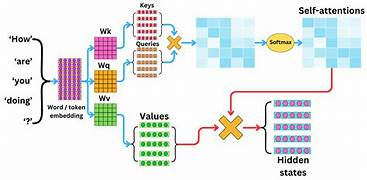

In [ ]:
vec1 = torch.zeros((100,128))
vec2 = torch.zeros((100,128))
vec3 = torch.zeros((100,128))

In [ ]:
vec1.shape,vec2.shape,vec3.shape

(torch.Size([100, 128]), torch.Size([100, 128]), torch.Size([100, 128]))

In [ ]:
Q = nn.Linear(128,128)
K = nn.Linear(128,128)
V = nn.Linear(128,128)

In [ ]:
q = Q(vec1)
k = K(vec2)
v = V(vec3)

In [ ]:
q.shape , k.shape , v.shape

(torch.Size([100, 128]), torch.Size([100, 128]), torch.Size([100, 128]))

In [ ]:
k_T = k.transpose(-1,-2)
k_T.shape

torch.Size([128, 100])

In [ ]:
dot = (q @ k_T)
dot.shape

torch.Size([100, 100])

In [ ]:
dot

tensor([[-0.0021, -0.0021, -0.0021,  ..., -0.0021, -0.0021, -0.0021],
        [-0.0021, -0.0021, -0.0021,  ..., -0.0021, -0.0021, -0.0021],
        [-0.0021, -0.0021, -0.0021,  ..., -0.0021, -0.0021, -0.0021],
        ...,
        [-0.0021, -0.0021, -0.0021,  ..., -0.0021, -0.0021, -0.0021],
        [-0.0021, -0.0021, -0.0021,  ..., -0.0021, -0.0021, -0.0021],
        [-0.0021, -0.0021, -0.0021,  ..., -0.0021, -0.0021, -0.0021]],
       grad_fn=<MmBackward0>)

In [ ]:
soft_dot = torch.softmax(dot/math.sqrt(embedding_dim),dim=-1)
soft_dot

tensor([[0.0100, 0.0100, 0.0100,  ..., 0.0100, 0.0100, 0.0100],
        [0.0100, 0.0100, 0.0100,  ..., 0.0100, 0.0100, 0.0100],
        [0.0100, 0.0100, 0.0100,  ..., 0.0100, 0.0100, 0.0100],
        ...,
        [0.0100, 0.0100, 0.0100,  ..., 0.0100, 0.0100, 0.0100],
        [0.0100, 0.0100, 0.0100,  ..., 0.0100, 0.0100, 0.0100],
        [0.0100, 0.0100, 0.0100,  ..., 0.0100, 0.0100, 0.0100]],
       grad_fn=<SoftmaxBackward0>)

In [ ]:
ans = (soft_dot @ v)
ans.shape

torch.Size([100, 128])

In [ ]:
# Self attention
### z = softmax((Q . K_t)/sqrt(d_k)) . V
### input dim = [batch_size,seq_len,embedding_dim] = [32,100,128]
### ouput_dim = [batch_size,seq_len,embedding_dim] = [32,100,128]
## Query , Key , Value => dim =[128,128] => linear layer (back propogation to update the weights)
### Operations
## Q . k^t = [100,128] , [128,100] = [100,100]
## (Q.k^t)/sqrt(d_k) = [100,100]
## softmax((Q.k^t)/sqrt(d_k)) = [100,100]
## softmax((Q.k^t)/sqrt(d_k)) . V = [100,100] . [100,128] = [100,128]

In [ ]:
### Self Attention
class SelfAttention(nn.Module):
  def __init__(self,seq_len,embedding_dim):
    super().__init__()
    self.d_k = embedding_dim
    self.Q = nn.Linear(self.d_k,self.d_k)
    self.K = nn.Linear(self.d_k,self.d_k)
    self.V = nn.Linear(self.d_k,self.d_k)
  def forward(self,X):
    q = self.Q(X)
    k = self.K(X)
    v = self.V(X)
    k_t = k.transpose(-1,-2)
    attention_scores = torch.softmax((q @ k_t)/math.sqrt(self.d_k),dim=-1) @ v
    return attention_scores

In [ ]:
attention = SelfAttention(sequence_length,embedding_dim)

In [ ]:
attention(pe_input).shape

torch.Size([32, 100, 128])

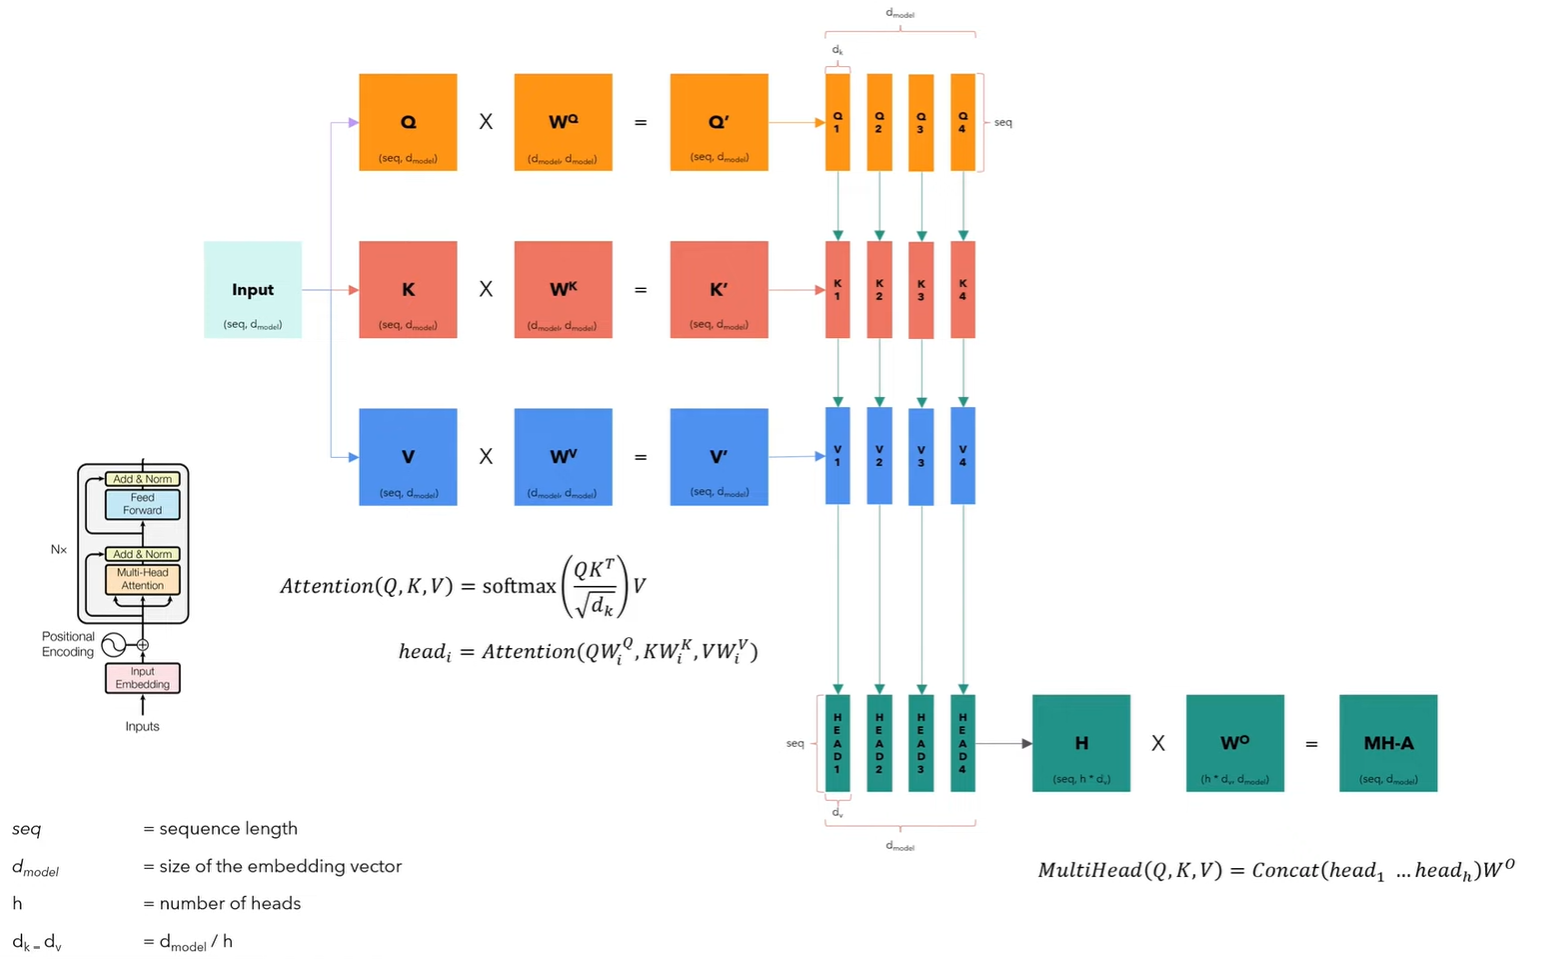

In [ ]:
## Multi Head Attention
### z = softmax((Q . K_t)/sqrt(d_k)) . V
### attention heads =
### input dim = [batch_size,seq_len,embedding_dim] = [32,100,128]
### ouput_dim = [batch_size,seq_len,embedding_dim] = [32,100,128]
## Query , Key , Value => dim =[128,128] => linear layer (back propogation to update the weights)
### Operations
## Q . k^t = [100,128] , [128,100] = [100,100]
## (Q.k^t)/sqrt(d_k) = [100,100]
## softmax((Q.k^t)/sqrt(d_k)) = [100,100]
## softmax((Q.k^t)/sqrt(d_k)) . V = [100,100] . [100,128] = [100,128]

In [ ]:
vec1 = torch.zeros((100,128))
vec2 = torch.zeros((100,128))
vec3 = torch.zeros((100,128))

In [ ]:
q = Q(vec1)
k = K(vec2)
v = V(vec3)

In [ ]:
q.shape,k.shape,v.shape

(torch.Size([100, 128]), torch.Size([100, 128]), torch.Size([100, 128]))

In [ ]:
heads = 8
head_dim = embedding_dim // heads
print(heads,head_dim)

8 16


In [ ]:
q_ = q.view(sequence_length,heads,head_dim)
k_ = k.view(sequence_length,heads,head_dim)
v_ = v.view(sequence_length,heads,head_dim)
q_

tensor([[[-0.0024, -0.0347,  0.0707,  ..., -0.0714, -0.0676, -0.0331],
         [ 0.0406,  0.0341,  0.0129,  ..., -0.0086, -0.0866,  0.0403],
         [-0.0348,  0.0837, -0.0599,  ..., -0.0422,  0.0036, -0.0812],
         ...,
         [ 0.0192,  0.0270, -0.0209,  ...,  0.0650,  0.0631,  0.0282],
         [-0.0740,  0.0267,  0.0135,  ...,  0.0486, -0.0420,  0.0610],
         [ 0.0561, -0.0135, -0.0164,  ..., -0.0490, -0.0782, -0.0159]],

        [[-0.0024, -0.0347,  0.0707,  ..., -0.0714, -0.0676, -0.0331],
         [ 0.0406,  0.0341,  0.0129,  ..., -0.0086, -0.0866,  0.0403],
         [-0.0348,  0.0837, -0.0599,  ..., -0.0422,  0.0036, -0.0812],
         ...,
         [ 0.0192,  0.0270, -0.0209,  ...,  0.0650,  0.0631,  0.0282],
         [-0.0740,  0.0267,  0.0135,  ...,  0.0486, -0.0420,  0.0610],
         [ 0.0561, -0.0135, -0.0164,  ..., -0.0490, -0.0782, -0.0159]],

        [[-0.0024, -0.0347,  0.0707,  ..., -0.0714, -0.0676, -0.0331],
         [ 0.0406,  0.0341,  0.0129,  ..., -0

In [ ]:
q_.shape ,k_.shape,v_.shape
## here the each word is represented in 128 dim vector
## then this vector is divided in to 8 parts with each word 16 dim vector

(torch.Size([100, 8, 16]), torch.Size([100, 8, 16]), torch.Size([100, 8, 16]))

In [ ]:
q_ = q.view(heads,sequence_length,head_dim)
k_ = k.view(heads,sequence_length,head_dim)
v_ = v.view(heads,sequence_length,head_dim)

In [ ]:
q_.shape ,k_.shape,v_.shape
## each head as given 100 sentence and in it each word is 16 dim vector
## this is done such that for that given 100 sentence each head has their different perspective

(torch.Size([8, 100, 16]), torch.Size([8, 100, 16]), torch.Size([8, 100, 16]))

In [ ]:
q_.transpose(1,2).shape , q_.shape

(torch.Size([8, 16, 100]), torch.Size([8, 100, 16]))

In [ ]:
# [100,16] [16,100] = [100,100]
k_t = k_.transpose(-1,-2)

In [ ]:
attention_scores = torch.softmax((q_ @ k_t)/math.sqrt(head_dim),dim=-1) @ v

In [ ]:
attention_scores.shape

torch.Size([1, 8, 100, 128])

In [ ]:
W_o = nn.Linear(embedding_dim,embedding_dim)

In [ ]:
w_0 = W_o(attention_scores)

In [ ]:
w_0.shape

torch.Size([8, 100, 128])

In [ ]:
out = out.transpose(1, 2).contiguous().view(batch_size, seq_len, dim)


In [ ]:
attention_scores.unsqueeze_(0).shape

torch.Size([1, 8, 100, 128])

In [ ]:
attention_scores.transpose(1,2).contiguous().view(batch_size,sequence_length,embedding_dim).shape

RuntimeError: shape '[32, 100, 128]' is invalid for input of size 102400

In [ ]:
attention_scores.transpose(1,2).shape

torch.Size([1, 100, 8, 128])

In [ ]:
out = torch.zeros(32,8,100,16)

In [ ]:
out.transpose(1,2).contiguous().view(32,100,128).shape

torch.Size([32, 100, 128])

In [ ]:
class MultiHeadAttention(nn.Module):
  def __init__(self,seq_len,embedding_dim):
    super().__init__()
    self.seq_len = seq_len
    self.heads = 8
    self.head_dim = embedding_dim // self.heads
    self.Q = nn.Linear(embedding_dim,embedding_dim)
    self.K = nn.Linear(embedding_dim,embedding_dim)
    self.V = nn.Linear(embedding_dim,embedding_dim)
    self.linear_fc = nn.Linear(embedding_dim,embedding_dim)
    self.softmax = nn.Softmax(dim=-1)
  def forward(self,x):
    print("In attention")
    batch_size,seq_len,embeddding_size = x.size()
    q_ = self.Q(x).view(batch_size,self.seq_len,self.heads,self.head_dim).transpose(1,2)
    k_ = self.Q(x).view(batch_size,self.seq_len,self.heads,self.head_dim).transpose(1,2)
    v_ = self.Q(x).view(batch_size,self.seq_len,self.heads,self.head_dim).transpose(1,2)
    k_t = k_.transpose(-2,-1)
    attention_scores = torch.softmax((q_ @ k_t)/math.sqrt(embedding_dim),dim=-1) @ v_
    out = attention_scores.transpose(1,2).contiguous().view(batch_size,seq_len,embedding_dim)
    return self.linear_fc(out)


In [ ]:
multi_head = MultiHeadAttention(sequence_length,embedding_dim)

In [ ]:
multi_head(pe_input).shape

In attention


torch.Size([32, 100, 128])

In [ ]:
multi_input = multi_head(pe_input)

In attention


## ADD

In [ ]:
vec = torch.zeros((32,100,128))
copy_multi = multi_input

In [ ]:
vec.shape , copy_multi.shape

(torch.Size([32, 100, 128]), torch.Size([32, 100, 128]))

In [ ]:
(vec + copy_multi).shape

torch.Size([32, 100, 128])

##  Norm

In [ ]:
## input = [batch_size,seq_len,embedding_dim] => [32,100,128]
## mean , std => dim = -1 and keepdim= true => [batch_size,seq_len]


In [ ]:
vec = torch.ones((batch_size,sequence_length,embedding_dim))
vec.shape

torch.Size([32, 100, 128])

In [ ]:
mean = vec.mean(dim=-1,keepdim=True)

In [ ]:
mean.shape

torch.Size([32, 100, 1])

In [ ]:
std = vec.std(dim=-1,keepdim=True) # keepdim=true had did to solve the broadcast issuse
std.shape

torch.Size([32, 100, 1])

In [ ]:
norm = ((vec - mean )/(std + 0.0001))

In [ ]:
norm.shape

torch.Size([32, 100, 128])

In [ ]:
alpha = torch.ones((32,100))
beta = torch.ones((32,100))
alpha.shape

torch.Size([32, 100])

In [ ]:
alpha @ norm # this is wrong
## if we tke the dim of alpha and beta = [32,100] then each row as it unique alpha and beta but alpha and beta are common for all rows i.e they are shared between rows

tensor([[[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]],

        [[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]],

        [[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]],

        ...,

        [[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0., 

In [ ]:
alpha = torch.ones((128))
beta = torch.ones((128))

In [ ]:
alpha.shape , norm.shape

(torch.Size([128]), torch.Size([32, 100, 128]))

In [ ]:
((norm *alpha) + beta).shape

torch.Size([32, 100, 128])

 Layer Norm uses element-wise scaling (*) to adjust the normalized distribution of existing features, whereas matrix multiplication (@) fundamentally changes the features into a new representation.


In [ ]:
## add and norm layer

## Adding
## it is done suppose not important details are able to caputre during multihead attention so we retain the original vector
## multihead input = [32,100,128]
## positinal input = [32,100,128]
## element wise addition (+)
## output = [32,100,128]
## Normalization
## it is done such that are model can ignore the covariate shift and normalization is good and it is layer normalization i.e to reduce the impact of the padding thats why the layer norma is did
## added output = [32,100,128]
## alpha , beta = [128] (element wise)
## mean , std = [32,100,1] (to avoid the broadcast shift)
## final formula (element wise) = alpha * (x_i - mean / (std + eps)) + beta
## final shape = [32,100,128]

In [ ]:
class LayerNorm(nn.Module):
  def __init__(self):
    super().__init__()
    self.eps = 0.01
    self.alpha = nn.Parameter(torch.ones(1))
    self.beta = nn.Parameter(torch.ones(1))

  def forward(self,X):
      mean = X.mean(dim=-1,keepdim=True)
      std = X.std(dim=-1,keepdim=True)
      print("In layer norm")
      return (self.alpha * ((X - mean)/(std + self.eps)) + self.beta)

In [ ]:
add = (vec + copy_multi)
layer = LayerNorm()
add_norm = layer(add)

In layer norm


## Feed Forward Network

In [ ]:
## It is and neural network is added to introduce some non linearity in data
## here 2 layers are
## layer 1 : 2048 neurons and relu as activation
## layer 2 : 512 neuron and linear as activation
## input layer as 512 entery noed i.e one row at a time

In [ ]:
layer_1 = nn.Linear(128,2048)
activation = nn.ReLU()
layer_2 = nn.Linear(2048,128) # because the embedding dim = 128

In [ ]:
vec = torch.zeros((32,100,128))

In [ ]:
lay_1 = layer_1(vec)
relu = activation(lay_1)
lay_2 = layer_2(relu)

In [ ]:
vec.shape , lay_1.shape , relu.shape , lay_2.shape

(torch.Size([32, 100, 128]),
 torch.Size([32, 100, 2048]),
 torch.Size([32, 100, 2048]),
 torch.Size([32, 100, 128]))

In [ ]:
class FeedForwardNetwork(nn.Module):
  def __init__(self,embedding_dim):
    super().__init__()
    self.layer_1 = nn.Linear(embedding_dim,2048)
    self.layer_2 = nn.Linear(2048,embedding_dim)

  def forward(self,X):
    print("in feed forward")
    return self.layer_2(torch.relu(self.layer_1(X)))

In [ ]:
fnn = FeedForwardNetwork(embedding_dim)
fnn(add_norm).shape

in feed forward


torch.Size([32, 100, 128])

## Residual Block'

## This block contain the residual connections
## With help of this connection we able to add the inputs

In [ ]:
class ResidualBlock(nn.Module):
  def __init__(self):
    super().__init__()
    self.layer_norm = LayerNorm()
  def forward(self,X,sublayer):
    print("in residual ")
    return X + sublayer(self.layer_norm(X)) # ada and norm

## Encoder Block
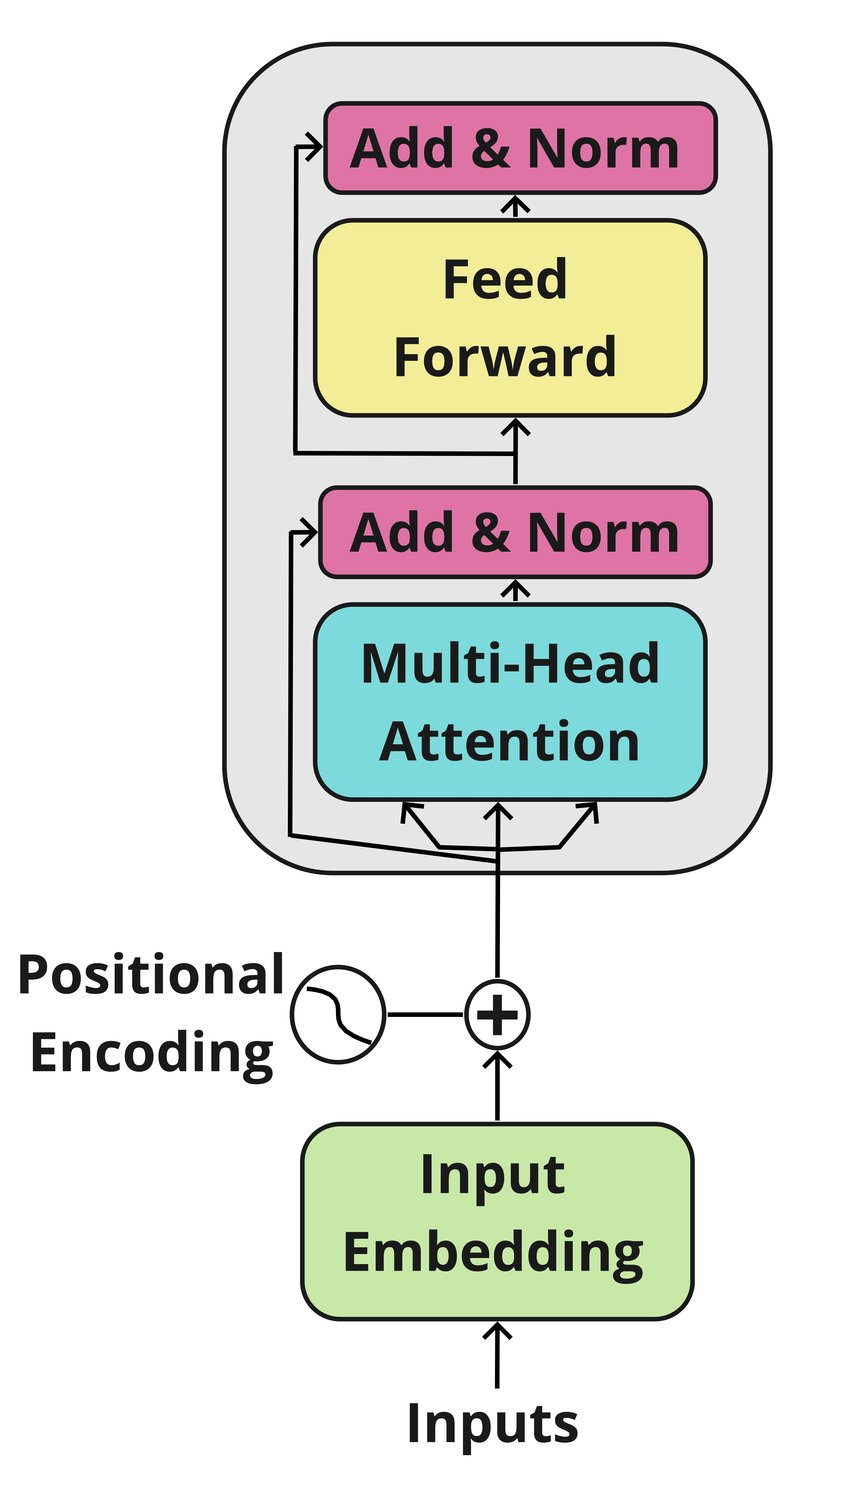![![image.png](
)image.png](
)

In [ ]:
class EncoderBlock(nn.Module):
  def __init__(self,self_attention:MultiHeadAttention,feed_forward:FeedForwardNetwork):
    super().__init__()
    self.attention_block = self_attention
    self.feed_forward_block = feed_forward
    self.residual_block = nn.ModuleList([ResidualBlock() for _ in range(2)])
  def forward(self,X):
    print("In encoder block")
    X = self.residual_block[0](X,lambda x: self.attention_block(X))
    print("Completed residual 1")
    X = self.residual_block[1](X,lambda x: self.feed_forward_block(X))
    print("completed residual 2")
    return X

In [ ]:
multihead = MultiHeadAttention(sequence_length, embedding_dim)
fnn = FeedForwardNetwork(embedding_dim)
encoder = EncoderBlock(self_attention=multihead,feed_forward=fnn)


In [ ]:
encoder

EncoderBlock(
  (attention_block): MultiHeadAttention(
    (Q): Linear(in_features=128, out_features=128, bias=True)
    (K): Linear(in_features=128, out_features=128, bias=True)
    (V): Linear(in_features=128, out_features=128, bias=True)
    (linear_fc): Linear(in_features=128, out_features=128, bias=True)
    (softmax): Softmax(dim=-1)
  )
  (feed_forward_block): FeedForwardNetwork(
    (layer_1): Linear(in_features=128, out_features=2048, bias=True)
    (layer_2): Linear(in_features=2048, out_features=128, bias=True)
  )
  (residual_block): ModuleList(
    (0-1): 2 x ResidualBlock(
      (layer_norm): LayerNorm()
    )
  )
)

In [ ]:
# Building Encoder
# An Encoder can have several Encoder Blocks
class Encoder(nn.Module):

    # The Encoder takes in instances of 'EncoderBlock'
    def __init__(self, layers: nn.ModuleList) -> None:
        super().__init__()
        self.layers = layers # Storing the EncoderBlocks
        self.norm = LayerNorm() # Layer for the normalization of the output of the encoder layers

    def forward(self, x):
        # Iterating over each EncoderBlock stored in self.layers
        for layer in self.layers:
            x = layer(x) # Applying each EncoderBlock to the input tensor 'x'
        print("encoder Completed")
        return self.norm(x) # Normalizing output

In [ ]:
encoder_model = Encoder(layers=nn.ModuleList([encoder]))

In [ ]:
encoder_model(pe_input).shape

NameError: name 'pe_input' is not defined

In [ ]:
layers = nn.ModuleList([encoder])

In [ ]:
for layer in layers:
  print(layer)
  print("---")
  print(layer(pe_input).shape)


EncoderBlock(
  (attention_block): MultiHeadAttention(
    (Q): Linear(in_features=128, out_features=128, bias=True)
    (K): Linear(in_features=128, out_features=128, bias=True)
    (V): Linear(in_features=128, out_features=128, bias=True)
    (linear_fc): Linear(in_features=128, out_features=128, bias=True)
    (softmax): Softmax(dim=-1)
  )
  (feed_forward_block): FeedForwardNetwork(
    (layer_1): Linear(in_features=128, out_features=2048, bias=True)
    (layer_2): Linear(in_features=2048, out_features=128, bias=True)
  )
  (residual_block): ModuleList(
    (0-1): 2 x ResidualBlock(
      (layer_norm): LayerNorm()
    )
  )
)
---
In encoder block
in residual 
In layer norm
In attention
Completed residual 1
in residual 
In layer norm
in feed forward
completed residual 2
torch.Size([32, 100, 128])


## Decoder Block

## Masked Attention
### It is an type of multihead attention where the future words are committed in order to get the model working in sequence-2-sequence task which is essential for predicting next word by the context of previous word and this able for transformer to work in "auto regressive mode while making prediction and non auto regressive mode while training"
### Masking is done before going to softmax layer with the matrix in this way and matrix containing zero below diagonal and -infifnity above diagonal is added with the matrix and then send to the softmax layer and softmax(-inifinity) = 0 .

In [ ]:
x = torch.zeros((32,100,128))

In [ ]:
x.shape

torch.Size([32, 100, 128])

In [ ]:
Q = nn.Linear(128,128)
K = nn.Linear(128,128)
V = nn.Linear(128,128)

In [ ]:
q = Q(x)
k = K(x)
v = V(x)

In [ ]:
q.shape,k.shape,v.shape

(torch.Size([32, 100, 128]),
 torch.Size([32, 100, 128]),
 torch.Size([32, 100, 128]))

In [ ]:
## converting to heads
q =q.view(32,100,8,16)
k =k.view(32,100,8,16)
v =v.view(32,100,8,16)


In [ ]:
q = q.transpose(2,1)
k = k.transpose(2,1)
v = v.transpose(2,1)

In [ ]:
q.shape , k.shape , v.shape

(torch.Size([32, 8, 100, 16]),
 torch.Size([32, 8, 100, 16]),
 torch.Size([32, 8, 100, 16]))

In [ ]:
((q @ k.transpose(-1,-2) ) @ v).shape

torch.Size([32, 8, 100, 16])

In [ ]:
# 1. Initialize a matrix of zeros
shape = (32, 8, 100, 100)
matrix = torch.zeros(shape)

# 2. Fill the elements above the diagonal (offset 1) with -inf
# diagonal=1 targets everything strictly above the main diagonal
mask = torch.triu(torch.ones(100, 100), diagonal=1).bool()
matrix[..., mask] = float('-inf')

In [ ]:
matrix

tensor([[[[0., -inf, -inf,  ..., -inf, -inf, -inf],
          [0., 0., -inf,  ..., -inf, -inf, -inf],
          [0., 0., 0.,  ..., -inf, -inf, -inf],
          ...,
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.]],

         [[0., -inf, -inf,  ..., -inf, -inf, -inf],
          [0., 0., -inf,  ..., -inf, -inf, -inf],
          [0., 0., 0.,  ..., -inf, -inf, -inf],
          ...,
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.]],

         [[0., -inf, -inf,  ..., -inf, -inf, -inf],
          [0., 0., -inf,  ..., -inf, -inf, -inf],
          [0., 0., 0.,  ..., -inf, -inf, -inf],
          ...,
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.]],

         ...,

         [[0., -inf, -inf,  ..., -inf, -inf, -inf],
          [0., 0., -inf,  ..., -inf, -inf, -inf],
    

In [ ]:
mat = torch.zeros((32,8,100,100))

In [ ]:
mat.shape

torch.Size([32, 8, 100, 100])

In [ ]:
mask = torch.triu(mat,diagonal=1)

In [ ]:
mask.shape

torch.Size([32, 8, 100, 100])

In [ ]:
mask = torch.triu(torch.ones(100, 100), diagonal=1).bool()

In [ ]:
mat[...,mask] = float('-inf')

In [ ]:
torch.nn.functional.softmax(((q @ k.transpose(-1,-2) ) + mat),dim=-1) # transformuing the matrix

tensor([[[[1.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          [0.5000, 0.5000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          [0.3333, 0.3333, 0.3333,  ..., 0.0000, 0.0000, 0.0000],
          ...,
          [0.0102, 0.0102, 0.0102,  ..., 0.0102, 0.0000, 0.0000],
          [0.0101, 0.0101, 0.0101,  ..., 0.0101, 0.0101, 0.0000],
          [0.0100, 0.0100, 0.0100,  ..., 0.0100, 0.0100, 0.0100]],

         [[1.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          [0.5000, 0.5000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          [0.3333, 0.3333, 0.3333,  ..., 0.0000, 0.0000, 0.0000],
          ...,
          [0.0102, 0.0102, 0.0102,  ..., 0.0102, 0.0000, 0.0000],
          [0.0101, 0.0101, 0.0101,  ..., 0.0101, 0.0101, 0.0000],
          [0.0100, 0.0100, 0.0100,  ..., 0.0100, 0.0100, 0.0100]],

         [[1.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          [0.5000, 0.5000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          [0.3333, 0.3333, 0.3333,  ..., 0

In [ ]:
(torch.nn.functional.softmax(((q @ k.transpose(-1,-2) ) + mat),dim=-1) @ v)

tensor([[[[-0.0089,  0.0014, -0.0447,  ..., -0.0459,  0.0038,  0.0470],
          [-0.0089,  0.0014, -0.0447,  ..., -0.0459,  0.0038,  0.0470],
          [-0.0089,  0.0014, -0.0447,  ..., -0.0459,  0.0038,  0.0470],
          ...,
          [-0.0089,  0.0014, -0.0447,  ..., -0.0459,  0.0038,  0.0470],
          [-0.0089,  0.0014, -0.0447,  ..., -0.0459,  0.0038,  0.0470],
          [-0.0089,  0.0014, -0.0447,  ..., -0.0459,  0.0038,  0.0470]],

         [[-0.0248,  0.0807, -0.0801,  ..., -0.0866,  0.0391,  0.0008],
          [-0.0248,  0.0807, -0.0801,  ..., -0.0866,  0.0391,  0.0008],
          [-0.0248,  0.0807, -0.0801,  ..., -0.0866,  0.0391,  0.0008],
          ...,
          [-0.0248,  0.0807, -0.0801,  ..., -0.0866,  0.0391,  0.0008],
          [-0.0248,  0.0807, -0.0801,  ..., -0.0866,  0.0391,  0.0008],
          [-0.0248,  0.0807, -0.0801,  ..., -0.0866,  0.0391,  0.0008]],

         [[-0.0869,  0.0004, -0.0823,  ...,  0.0584,  0.0837, -0.0733],
          [-0.0869,  0.0004, -

In [ ]:
(torch.nn.functional.softmax(((q @ k.transpose(-1,-2) ) + mat),dim=-1) @ v ).transpose(2,1).contiguous().view(32,100,128).shape
#[32,8,100,16]

torch.Size([32, 100, 128])

In [ ]:
class MaskMultiHeadAttention(nn.Module):
  def __init__(self,embedding_dim,heads):
    super().__init__()
    self.d_k = embedding_dim
    assert  embedding_dim % heads == 0
    self.heads = heads
    self.embed = embedding_dim // heads
    self.Q = nn.Linear(self.d_k,self.d_k)
    self.K = nn.Linear(self.d_k,self.d_k)
    self.V = nn.Linear(self.d_k,self.d_k)

  def forward(self,X,mask):
    batch_size,seq_len,embedding_dim = X.size()
    print("Multihead masked attention")
    q = self.Q(X).view(batch_size,seq_len,self.heads,self.embed).transpose(2,1)
    k = self.K(X).view(batch_size,seq_len,self.heads,self.embed).transpose(2,1)
    v = self.V(X).view(batch_size,seq_len,self.heads,self.embed).transpose(2,1)
    k_t = k.transpose(-1,-2)
    s = (q @ k_t)
    if mask :
      mat = torch.zeros(s.size())
      mask = torch.triu(torch.ones(seq_len, seq_len), diagonal=1).bool()
      mat[...,mask] = float("-inf")
      s = s + mat
    s = s / math.sqrt(self.embed) #the embedding dim in the multihead attention
    attention_scores = torch.nn.functional.softmax(s,dim=-1) @ v
    return attention_scores.transpose(2,1).contiguous().view(batch_size,seq_len,embedding_dim)

In [ ]:
model = MaskMultiHeadAttention(embedding_dim,8)

In [ ]:
model

MaskMultiHeadAttention(
  (Q): Linear(in_features=128, out_features=128, bias=True)
  (K): Linear(in_features=128, out_features=128, bias=True)
  (V): Linear(in_features=128, out_features=128, bias=True)
)

In [ ]:
model(x,1).shape

NameError: name 'x' is not defined

## Cross Attention
### It is an important part in transformer decoder architecture. I this part the key and value from encoder block is given and just query from the last layer of decoder block is taken and pass to cross attention block here the attention also able to capture the prespective of previous encoder block.
### This is similar to other previous encoder decoder architecture prposed by  Luong and Bahdanau in their Luong and Bahdanau attention here also some importance from the encoder is captured able to jusity the input sequence importance also.
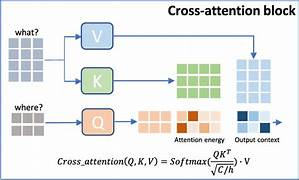

here the where? => from teh docoder and what? => is from the encoder

In [ ]:
encoder_x = torch.zeros((32,100,128))
decoder_x = torch.zeros((32,100,128))
encoder_x.shape , decoder_x.shape

(torch.Size([32, 100, 128]), torch.Size([32, 100, 128]))

In [ ]:
Q = nn.Linear(128,128)
K = nn.Linear(128,128)
V = nn.Linear(128,128)

In [ ]:
q = Q(decoder_x) # from decoder block
k = K(encoder_x)  # from encoder block
v = V(encoder_x) # from encoder block

In [ ]:
## converting to heads
q =q.view(32,100,8,16)
k =k.view(32,100,8,16)
v =v.view(32,100,8,16)

In [ ]:
q = q.transpose(2,1)
k = k.transpose(2,1)
v = v.transpose(2,1)

In [ ]:
q.shape

torch.Size([32, 8, 100, 16])

In [ ]:
k_t = k.transpose(-1,-2)

In [ ]:
(torch.nn.functional.softmax(((q @ k.transpose(-1,-2) ) / math.sqrt(16)),dim=-1) @ v ).transpose(2,1).contiguous().view(32,100,128).shape # 16 = embedding dim after transforming to heads

torch.Size([32, 100, 128])

In [ ]:
class CrossAttention(nn.Module):
  def __init__(self,embedding_dim,heads):
    super().__init__()
    self.d_k = embedding_dim
    assert  embedding_dim % heads == 0
    self.heads = heads
    self.head_dim = embedding_dim // heads
    self.Q = nn.Linear(self.d_k,self.d_k)
    self.K = nn.Linear(self.d_k,self.d_k)
    self.V = nn.Linear(self.d_k,self.d_k)
  def forward(self,encoder_x,decoder_x):
    print("Cross Attention")
    batch_size,seq_len,embedding = encoder_x.size()
    _,dec_seq_len,_ = decoder_x.size()
    q = self.Q(decoder_x).view(batch_size,dec_seq_len,self.heads,self.head_dim).transpose(2,1)
    k = self.K(encoder_x).view(batch_size,seq_len,self.heads,self.head_dim).transpose(2,1)
    v = self.V(encoder_x).view(batch_size,seq_len,self.heads,self.head_dim).transpose(2,1)
    k_t = k.transpose(-1,-2)
    s = (q @ k_t) / math.sqrt(self.head_dim)
    attention_scores = torch.nn.functional.softmax(s,dim=-1) @ v
    return attention_scores.transpose(2,1).contiguous().view(batch_size,dec_seq_len,embedding_dim)


In [ ]:
cross = CrossAttention(embedding_dim,8)

In [ ]:
cross

CrossAttention(
  (Q): Linear(in_features=128, out_features=128, bias=True)
  (K): Linear(in_features=128, out_features=128, bias=True)
  (V): Linear(in_features=128, out_features=128, bias=True)
)

In [ ]:
encoder_x = torch.zeros((32,100,128))
decoder_x =  torch.zeros((32,100,128))

In [ ]:
cross(encoder_x,decoder_x).shape


NameError: name 'cross' is not defined

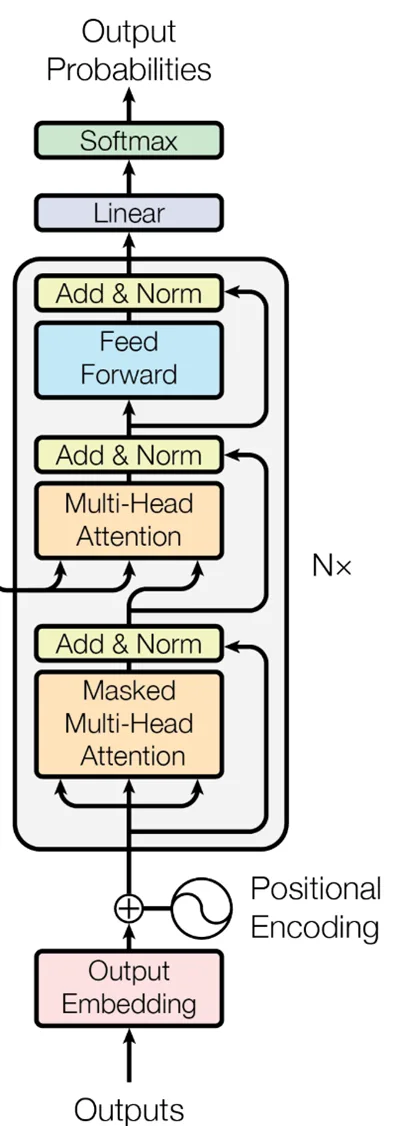

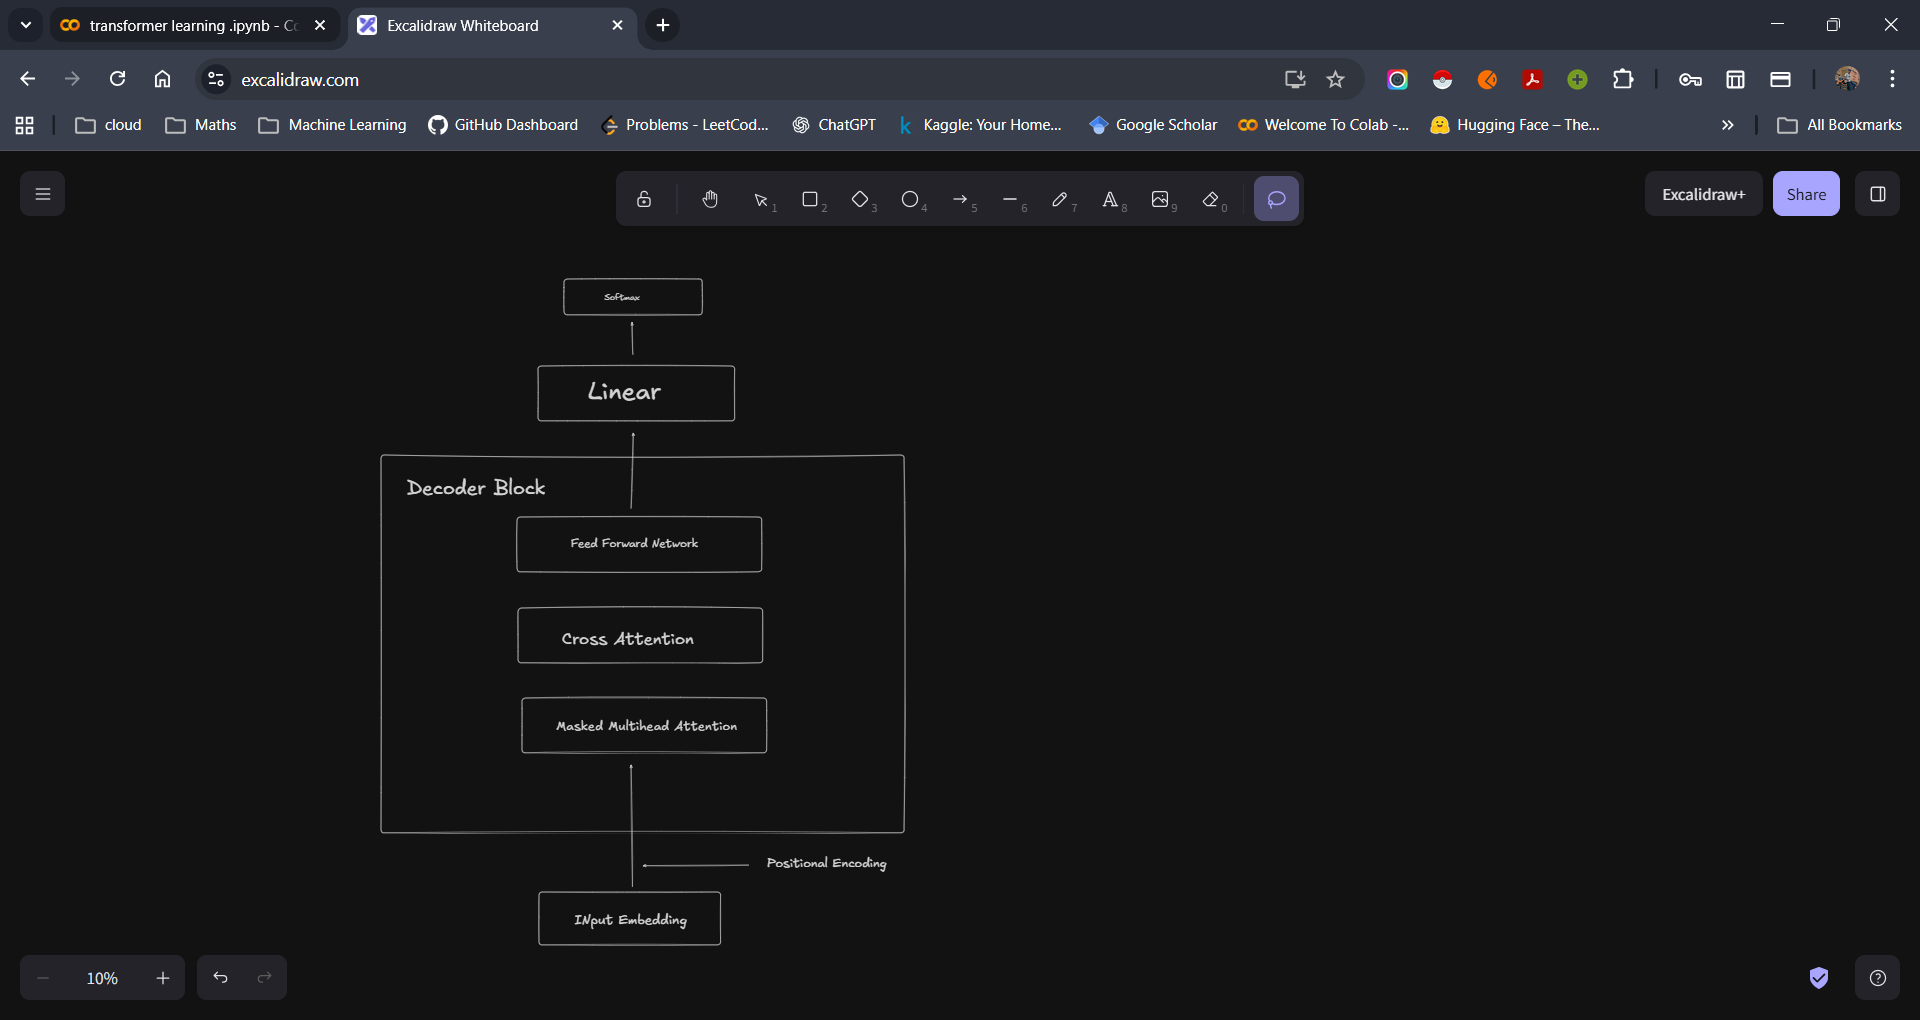

In [ ]:
## Decoder Block

## Decoder block contains

In [ ]:
class DecoderBlock(nn.Module):
  def __init__(self,masked_attention:MaskMultiHeadAttention , cross_attention:CrossAttention , feed_forward_network:FeedForwardNetwork):
    super().__init__()
    self.masked_attention = masked_attention
    self.cross_attention = cross_attention
    self.feed_forward = feed_forward_network
    self.residual_block = nn.ModuleList([ResidualBlock() for _ in range(3)])

  def forward(self,encoder_x,decoder_x,mask):
    ## decoder_x = X
    ## encoder_x = from encoder
    print("residual 1")
    decoder_x = self.residual_block[0](decoder_x,lambda x: self.masked_attention(x,mask))
    print("residual 2")
    X = self.residual_block[1](decoder_x,lambda x:self.cross_attention(encoder_x,x))
    print("residual 3")
    X = self.residual_block[2](X, lambda x:self.feed_forward(x))
    return X

In [ ]:
mask_multihead = MaskMultiHeadAttention(embedding_dim,8)
cross_attention = CrossAttention(embedding_dim,8)
feed_forward = FeedForwardNetwork(embedding_dim)

In [ ]:
MaskMultiHeadAttention(128,8).__class__.__name__


'MaskMultiHeadAttention'

In [ ]:
decoder = DecoderBlock(masked_attention=mask_multihead,cross_attention=cross_attention,feed_forward_network=feed_forward)

In [ ]:
decoder

DecoderBlock(
  (masked_attention): MaskMultiHeadAttention(
    (Q): Linear(in_features=128, out_features=128, bias=True)
    (K): Linear(in_features=128, out_features=128, bias=True)
    (V): Linear(in_features=128, out_features=128, bias=True)
  )
  (cross_attention): CrossAttention(
    (Q): Linear(in_features=128, out_features=128, bias=True)
    (K): Linear(in_features=128, out_features=128, bias=True)
    (V): Linear(in_features=128, out_features=128, bias=True)
  )
  (feed_forward): FeedForwardNetwork(
    (layer_1): Linear(in_features=128, out_features=2048, bias=True)
    (layer_2): Linear(in_features=2048, out_features=128, bias=True)
  )
  (residual_block): ModuleList(
    (0-2): 3 x ResidualBlock(
      (layer_norm): LayerNorm()
    )
  )
)

In [ ]:
class Decoder(nn.Module):
  def __init__(self,layers:nn.ModuleList):
    super().__init__()
    self.layers = layers
    self.norm = LayerNorm()
  def forward(self,encder_x,decoder_x,mask):
    print("In decoder")
    for layer in self.layers:
      X = layer(encoder_x,decoder_x,mask)
    print("decoder exit")
    return self.norm(X)

In [ ]:
decoder_model = Decoder(nn.ModuleList([decoder]))

In [ ]:
output_ = decoder_model(encoder_x,decoder_x,1)

In decoder
residual 1
in residual 
In layer norm
Multihead masked attention
residual 2
in residual 
In layer norm
Cross Attention
residual 3
in residual 
In layer norm
in feed forward
decoder exit
In layer norm


In [ ]:
layers = nn.ModuleList(6*[decoder]) ## for multiple encoder / decoder blocks

In [ ]:
layers = nn.ModuleList([decoder])

In [ ]:
for i,layer in enumerate(layers):
  break

In [ ]:
[ResidualBlock() for _ in range(3)]

[ResidualBlock(
   (layer_norm): LayerNorm()
 ),
 ResidualBlock(
   (layer_norm): LayerNorm()
 ),
 ResidualBlock(
   (layer_norm): LayerNorm()
 )]

In [ ]:
residual_ = nn.ModuleList([ResidualBlock() for _ in range(3)])

In [ ]:
for residual in residual_:
  break

In [ ]:
#self.residual_block[0](decoder_x,lambda x: self.masked_attention(x,mask))
## why this lambda x: self.masked_attention(x,mask)
# => se the residual block goes to x + sublayer(nomr(x))
## here x = deocder_x and the sublayer is the self.attention()
## but why lambda so the reason is that the sublayer consist and function inside it wich written some value so lambda x: self.attention(x,1)
## so the written value is x ( return from norm) and it is similar to the first input
## so here in the lambda we just write what new for that sublayer other is x

In [ ]:
### sublayer = maks_attention
## self.norm => written value (x)
## other argument for this which is new is (mask)

# Output Decoder Block

In [ ]:
### Output from decoder [32,100,128]
###

In [ ]:
import torch
import torch.nn as nn

class TransformerOutputHead(nn.Module):
    def __init__(self, d_model: int, vocab_size: int):
        super().__init__()
        self.projection_layer = nn.Linear(d_model, vocab_size)
        self.softmax = nn.Softmax(dim=-1)

    def forward(self, decoder_output_tensor):
        logits = self.projection_layer(decoder_output_tensor)
        probabilities = self.softmax(logits)

        return probabilities



In [ ]:
vocab_size = 1000
d_model = 128

In [ ]:
output = TransformerOutputHead(d_model,vocab_size)

In [ ]:
output

TransformerOutputHead(
  (projection_layer): Linear(in_features=128, out_features=1000, bias=True)
  (softmax): Softmax(dim=-1)
)

In [ ]:
output(output_)
## return and vocab size softmax for each token in all batch
## 32 sentence in batch where each sentence ad 100 tokens and fro each token and vocab size vector for task like machine translation / next word prediction / etc

(tensor([[[0.0011, 0.0003, 0.0017,  ..., 0.0004, 0.0005, 0.0007],
          [0.0011, 0.0003, 0.0017,  ..., 0.0004, 0.0005, 0.0007],
          [0.0011, 0.0003, 0.0017,  ..., 0.0004, 0.0005, 0.0007],
          ...,
          [0.0011, 0.0003, 0.0017,  ..., 0.0004, 0.0005, 0.0007],
          [0.0011, 0.0003, 0.0017,  ..., 0.0004, 0.0005, 0.0007],
          [0.0011, 0.0003, 0.0017,  ..., 0.0004, 0.0005, 0.0007]],
 
         [[0.0011, 0.0003, 0.0017,  ..., 0.0004, 0.0005, 0.0007],
          [0.0011, 0.0003, 0.0017,  ..., 0.0004, 0.0005, 0.0007],
          [0.0011, 0.0003, 0.0017,  ..., 0.0004, 0.0005, 0.0007],
          ...,
          [0.0011, 0.0003, 0.0017,  ..., 0.0004, 0.0005, 0.0007],
          [0.0011, 0.0003, 0.0017,  ..., 0.0004, 0.0005, 0.0007],
          [0.0011, 0.0003, 0.0017,  ..., 0.0004, 0.0005, 0.0007]],
 
         [[0.0011, 0.0003, 0.0017,  ..., 0.0004, 0.0005, 0.0007],
          [0.0011, 0.0003, 0.0017,  ..., 0.0004, 0.0005, 0.0007],
          [0.0011, 0.0003, 0.0017,  ...,

## Transformer Class
### The wrapper that wrapped both encoder and decoder block


In [ ]:
# Encoder
## input : [batch_size,seq_len]
## input_encoding = [batch_size,seq_len,embedding_dim]
## Positional_encoding + inout_embedding = [batch_size,seq_len,embedding_dim]
## Encoder block = [batch_size,seq_len,embedding_dim]
# Decoder
## input : [batch_size,seq_len]
## input_encoding = [batch_size,seq_len,embedding_dim]
## Positional_encoding + inout_embedding = [batch_size,seq_len,embedding_dim]
## Decoder block = [batch_size,seq_len,embedding_dim]
## Outputlayer = [batch_size,seq_len,vocab_size]
#,EncoderBlock:EncoderBlock,DecoderBlock:DecoderBlock,masked_multihead_attention:MaskMultiHeadAttention,cross_attention:CrossAttention,Residual:ResidualBlock,

In [ ]:
class Transformer(nn.Module):
  def __init__(self,vocab_size,embedding_dim,seq_len,batch_size,mask,encoder:Encoder,decoder:Decoder,Outputlayer:TransformerOutputHead,input_embedding_layer:InputEmbedding,output_embedding_layer:InputEmbedding,input_positional_encoding:PositionalEncoding,output_positional_encoding:PositionalEncoding):
    super().__init__()
    self.vocab_size = vocab_size
    self.embedding_dim = embedding_dim
    self.seq_len = seq_len
    self.batch_size = batch_size
    self.input_embedding = input_embedding_layer
    self.output_embedding = output_embedding_layer
    self.input_positional_layer = input_positional_encoding
    self.output_positional_layer = output_positional_encoding
    self.Encoder = encoder
    self.Decoder = decoder
    self.mask = mask
    self.OutputLayer = Outputlayer
  def forward(self,input_x,output_x):
    input_x = self.input_embedding(input_x)
    input_x = self.input_positional_layer(input_x)
    output_x = self.output_embedding(output_x)
    output_x = self.output_positional_layer(output_x)
    print("--"*40)
    X = self.Encoder(input_x)
    print("--"*40)
    X = self.Decoder(X,decoder_x,self.mask)
    print("--"*40)
    return self.OutputLayer(X)

In [ ]:
vocab_size = 1000
output_vocab_size = 1000
embedding_dim = 128
seq_len = 100
batch_size = 32
heads = 8
d_k = 16
mask = 1
## transformer related modules
# layer norm
layer_norm_encoder = LayerNorm()
layer_norm_decoder = LayerNorm()
## residual
residual_block_encoder = ResidualBlock()
residual_block_decoder = ResidualBlock()
# feed forward network
feed_forward_network_encoder = FeedForwardNetwork(embedding_dim)
feed_forward_network_deocder = FeedForwardNetwork(embedding_dim)
## attention
mask_multihead_attention = MaskMultiHeadAttention(embedding_dim,heads)
multihead_attention = MultiHeadAttention(seq_len,embedding_dim)
cross_attention = CrossAttention(embedding_dim,heads)
## input embedding
input_embedding = InputEmbedding(vocab_size,embedding_dim)
output_embedding = InputEmbedding(output_vocab_size,embedding_dim)
## positional encoding
positional_encoding_encoder = PositionalEncoding(vocab_size,embedding_dim,seq_len)
positional_encoding_decoder = PositionalEncoding(output_vocab_size,embedding_dim,seq_len)
## blocks
encoder_block = EncoderBlock(multihead_attention,feed_forward_network_encoder)
decoder_block = DecoderBlock(mask_multihead_attention,cross_attention,feed_forward_network_deocder)
encoder = Encoder(nn.ModuleList(6*[encoder_block]))
decoder = Decoder(nn.ModuleList(6*[decoder_block]))
output_layer = TransformerOutputHead(embedding_dim,output_vocab_size)
## transfoermer
transformer = Transformer(vocab_size,embedding_dim,seq_len,batch_size,mask,encoder,decoder,output_layer,input_embedding,output_embedding,positional_encoding_encoder,positional_encoding_decoder)

torch.Size([100, 128])
torch.Size([100, 128])
torch.Size([1, 100, 128])
torch.Size([100, 128])
torch.Size([100, 128])
torch.Size([1, 100, 128])


In [ ]:
input_x = torch.zeros((32,100))
output_x = torch.zeros((32,100))

In [ ]:
output = transformer(input_x.long(),output_x.long())

--------------------------------------------------------------------------------
In encoder block
in residual 
In layer norm
In attention
Completed residual 1
in residual 
In layer norm
in feed forward
completed residual 2
In encoder block
in residual 
In layer norm
In attention
Completed residual 1
in residual 
In layer norm
in feed forward
completed residual 2
In encoder block
in residual 
In layer norm
In attention
Completed residual 1
in residual 
In layer norm
in feed forward
completed residual 2
In encoder block
in residual 
In layer norm
In attention
Completed residual 1
in residual 
In layer norm
in feed forward
completed residual 2
In encoder block
in residual 
In layer norm
In attention
Completed residual 1
in residual 
In layer norm
in feed forward
completed residual 2
In encoder block
in residual 
In layer norm
In attention
Completed residual 1
in residual 
In layer norm
in feed forward
completed residual 2
encoder Completed
In layer norm
-----------------------------------

In [ ]:
output.shape

torch.Size([32, 100, 1000])